# Reasoning traces with the chess dataset

In [10]:
from datasets import load_dataset

ds = load_dataset("bonna46/Chess-FEN-and-NL-Format-30K-Dataset")

In [11]:
ds

DatasetDict({
    train: Dataset({
        features: ['FEN', 'Next move', 'FEN + Next move', 'NL Format of FEN'],
        num_rows: 30862
    })
})

In [12]:
from dotenv import load_dotenv
import os
from pathlib import Path

load_dotenv()

hf_root = Path(os.environ['HF_ROOT'])
hf_root.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(hf_root)
os.environ["TRANSFORMERS_CACHE"] = str(hf_root / "transformers")
os.environ["HF_DATASETS_CACHE"] = str(hf_root / "datasets")

In [13]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-1.7B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    trust_remote_code=True,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

print(f"Loaded {MODEL_ID} on {device} with dtype={dtype}")

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 4021.37it/s]


Loaded Qwen/Qwen3-1.7B on cuda with dtype=torch.bfloat16


In [14]:
def predict_next_move(fen, max_new_tokens=512):
    prompt = (
        "You are a chess expert. Given the position in FEN notation below, "
        "determine the best next move.\n\n"
        f"FEN: {fen}\n\n"
        "Output only the next move in standard algebraic notation (e.g. e4, Nf3, O-O). "
        "No explanation."
    )
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=True,
    )
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = tokenizer.decode(
        output[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=False,
    )

    think_start = generated.find("<think>")
    think_end = generated.find("</think>")

    if think_start != -1 and think_end != -1:
        thinking = generated[think_start + 7 : think_end].strip()
        response = generated[think_end + 8 :].strip()
    else:
        thinking = ""
        response = generated.strip()

    response = response.replace("<|im_end|>", "").strip()
    return thinking, response

In [15]:
import pandas as pd

ds_train = ds["train"]
results = []

for i in range(10):
    row = ds_train[i]
    fen = row["FEN"]
    actual_move = row["Next move"]

    thinking, predicted_move = predict_next_move(fen)

    results.append({
        "row": i,
        "fen": fen,
        "actual_move": actual_move,
        "predicted_move": predicted_move,
        "thinking": thinking,
    })
    print(f"Row {i}: actual={actual_move!r}  predicted={predicted_move!r}")

df_chess = pd.DataFrame(results)
df_chess[["row", "fen", "actual_move", "predicted_move"]]

Row 0: actual='a8a4'  predicted="<think>\nOkay, let's try to figure out the best next move for this chess position. The FEN given is:\n\nrnb2k1q/3ppp2/7b/1N3Bpr/QP3Pn1/P7/2PPN1R1/1RBK4 b - - 2 24\n\nFirst, I need to parse this FEN to understand the current board state. Let me break it down piece by piece.\n\nStarting from the top:\n\n- The first row is rnb2k1q/... So the first row (rank 1) is rnb2k1q. Let's see: the pieces are r, n, b, 2, k, 1, q. Wait, but in FEN, the ranks are written from the bottom up, right? Wait, no, actually, FEN is written from the bottom (rank 8) to the top (rank 1). Wait, no, actually, the first part of the FEN is the rank 8, then rank 7, etc. Wait, no, the standard FEN is written as: the first line is rank 8, then rank 7, down to rank 1. Wait, no, actually, the FEN is written as the first line is rank 8, then rank 7, then rank 6, etc. Wait, no, actually, the FEN is written as the first line is rank 1, then rank 2, etc. Wait, I need to be careful here.\n\nWai

KeyboardInterrupt: 

In [ ]:
SEP = "-" * 60

for _, row in df_chess.iterrows():
    print(f"=== Row {int(row['row'])} ===")
    print(f"FEN:       {row['fen']}")
    print(f"Actual:    {row['actual_move']}")
    print(f"Predicted: {row['predicted_move']}")
    if row["thinking"]:
        print(f"Thinking:\n{row['thinking'][:600]}")
    print(SEP)

=== Row 0 ===
FEN:       rnb2k1q/3ppp2/7b/1N3Bpr/QP3Pn1/P7/2PPN1R1/1RBK4 b - - 2 24
Actual:    a8a4
Predicted: <think>
Okay, let's try to figure out the best next move for this chess position. The FEN given is:

rnb2k1q/3ppp2/7b/1N3Bpr/QP3Pn1/P7/2PPN1R1/1RBK4 b - - 2 24

First, I need to parse this FEN to understand the current board state. Let me break it down piece by piece.

Starting from the top:

- The first row is rnb2k1q/... So the first row (rank 1) is rnb2k1q. Let's see: the pieces are r, n, b, 2, k, 1, q. Wait, but in FEN, the ranks are written from the bottom up, right? Wait, no, actually, FEN is written from the bottom (rank 8) to the top (rank 1). Wait, no, actually, the first part of the FEN is the rank 8, then rank 7, etc. Wait, no, the standard FEN is written as: the first line is rank 8, then rank 7, down to rank 1. Wait, no, actually, the FEN is written as the first line is rank 8, then rank 7, then rank 6, etc. Wait, no, actually, the FEN is written as the first line

In [17]:
first_fen = ds["train"][0]["FEN"]
first_actual = ds["train"][0]["Next move"]

# No max_new_tokens cap — let the model stop on its own EOS up to its full context window
prompt = (
    "You are a chess expert. Given the position in FEN notation below, "
    "determine the best next move.\n\n"
    f"FEN: {first_fen}\n\n"
    "Output only the next move in standard algebraic notation (e.g. e4, Nf3, O-O). "
    "No explanation."
)
messages = [{"role": "user", "content": prompt}]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True,
)
inputs = tokenizer(text, return_tensors="pt").to(device)

remaining_ctx = model.config.max_position_embeddings - inputs["input_ids"].shape[1]

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=remaining_ctx,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

generated = tokenizer.decode(
    output[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=False,
)

think_start = generated.find("<think>")
think_end = generated.find("</think>")

if think_start != -1 and think_end != -1:
    thinking_full = generated[think_start + 7 : think_end].strip()
    response_full = generated[think_end + 8 :].replace("<|im_end|>", "").strip()
else:
    thinking_full = ""
    response_full = generated.replace("<|im_end|>", "").strip()

print(f"FEN:       {first_fen}")
print(f"Actual:    {first_actual}")
print(f"Predicted: {response_full}")
print(f"\nFull thinking trace ({len(thinking_full)} chars):\n{thinking_full}")

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 10.91 GiB of which 3.38 MiB is free. Process 49994 has 6.96 GiB memory in use. Including non-PyTorch memory, this process has 3.94 GiB memory in use. Of the allocated memory 3.74 GiB is allocated by PyTorch, and 43.52 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [18]:
from tqdm import tqdm

In [20]:
def summarize_partial_thinking(partial_thinking):
    """Use the model (no thinking) to compress a partial reasoning trace."""
    prompt = (
        "Summarize the following partial chess reasoning in 2-3 sentences, "
        "preserving the key candidate moves and insights reached so far:\n\n"
        f"{partial_thinking}"
    )
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=400,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()


first_fen = ds["train"][0]["FEN"]
first_actual = ds["train"][0]["Next move"]

MAX_ITER = 5
MAX_NEW_TOKENS = 1024

base_prompt = (
    "You are a chess expert. Given the position in FEN notation below, "
    "determine the best next move.\n\n"
    f"FEN: {first_fen}\n\n"
    "Output only the next move in standard algebraic notation (e.g. e4, Nf3, O-O). "
    "No explanation."
)

current_prompt = base_prompt
iteration_log = []
final_response = None

for iteration in tqdm(range(MAX_ITER)):
    print(f"\n=== Iteration {iteration + 1} ===")

    messages = [{"role": "user", "content": current_prompt}]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=True,
    )
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = tokenizer.decode(
        output[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=False,
    )

    think_start = generated.find("<think>")
    think_end = generated.find("</think>")

    if think_end != -1:
        thinking = generated[think_start + 7 : think_end].strip() if think_start != -1 else ""
        response = generated[think_end + 8 :].replace("<|im_end|>", "").strip()
        iteration_log.append({"iteration": iteration + 1, "status": "done", "thinking_chars": len(thinking)})
        final_response = response
        print(f"Reasoning concluded. Predicted move: {response!r}")
        break

    # Reasoning still in progress — extract partial thinking, summarize, loop
    partial = generated[think_start + 7 :].strip() if think_start != -1 else generated.strip()
    print(f"Still reasoning ({len(partial)} chars generated). Summarizing...")
    summary = summarize_partial_thinking(partial)
    print(f"Summary: {summary}")

    iteration_log.append({"iteration": iteration + 1, "status": "continuing", "thinking_chars": len(partial), "summary": summary})

    current_prompt = (
        base_prompt + "\n\n"
        f"Reasoning so far (iteration {iteration + 1} summary): {summary}\n"
        "Continue your analysis and conclude with the best move."
    )
else:
    print("\nMax iterations reached without a final answer.")
    final_response = None

print(f"\nFEN:       {first_fen}")
print(f"Actual:    {first_actual}")
print(f"Predicted: {final_response}")
print(f"\nIterations: {len(iteration_log)}")
for entry in iteration_log:
    print(entry)

  0%|          | 0/5 [00:00<?, ?it/s]


=== Iteration 1 ===
Still reasoning (2811 chars generated). Summarizing...


 20%|██        | 1/5 [00:38<02:32, 38.06s/it]

Summary: The current position is a complex and highly imbalanced one, with the white king on e1 and the black king on e8, surrounded by a mix of pieces, including a queen on e8, a rook on e1, and a bishop on d1. The key candidate moves involve attacking the black king with a queen or bishop, or developing pieces to create a strong attack. The insights so far suggest that a strong attack on the black king is likely, with potential moves like Qe8 or Bf3 to threaten the king's safety.

=== Iteration 2 ===
Still reasoning (2758 chars generated). Summarizing...


 40%|████      | 2/5 [01:16<01:54, 38.09s/it]

...

Summary: The position is complex, with a strong pawn structure on the kingside and a queen on the 7th rank. The key candidate moves involve attacking the king and exploiting the queen's position. The insights so far suggest that a potential attack on the king with a knight or bishop is a strong possibility, while the queen's presence on the 7th rank offers a potential for a queen-side attack. The best move likely involves a dynamic, positional attack on the king, possibly with a knight or bishop, to create a strong follow-up.

=== Iteration 4 ===
Still reasoning (2878 chars generated). Summarizing...


 80%|████████  | 4/5 [02:31<00:37, 37.59s/it]

Summary: The position is complex, with a strong pawn structure on the second rank and a king on the seventh rank. Key candidate moves include developing the knight on c3 or e3, controlling the center with the queen, and preparing a potential attack on the king. The insights suggest that a strong central attack or a pawn push on e5 is likely, but the exact move depends on the opponent's response.

=== Iteration 5 ===
Still reasoning (2483 chars generated). Summarizing...


100%|██████████| 5/5 [03:09<00:00, 37.83s/it]

Summary: The position is complex, with a white king on e4, a queen on e5, and a strong pawn structure on the kingside. Key candidate moves include developing the knight to g5 or f3, preparing a queenside attack, or targeting the queen on e5. The position suggests a potential kingside attack or a queenside pawn storm, with the white king well positioned to support either approach. The key insight is that the white king is in a strong, central position, and the queen is a valuable piece that could be used to launch a decisive attack.

Max iterations reached without a final answer.

FEN:       rnb2k1q/3ppp2/7b/1N3Bpr/QP3Pn1/P7/2PPN1R1/1RBK4 b - - 2 24
Actual:    a8a4
Predicted: None

Iterations: 5
{'iteration': 1, 'status': 'continuing', 'thinking_chars': 2811, 'summary': "The current position is a complex and highly imbalanced one, with the white king on e1 and the black king on e8, surrounded by a mix of pieces, including a queen on e8, a rook on e1, and a bishop on d1. The key candidat

The summaries are so similar... was no reasoning progress made?

Generated 1024 tokens
Mean log prob:  -0.1344
</think> token: None


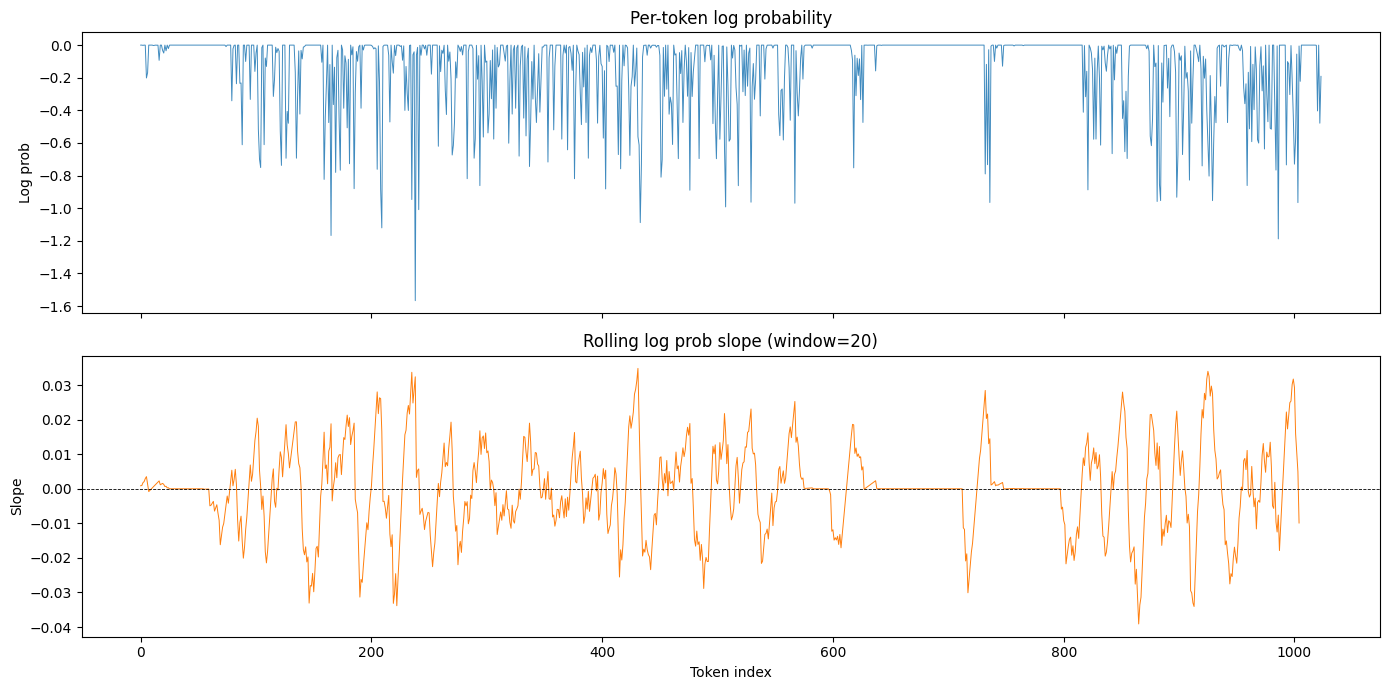

In [22]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

def rolling_slope(y, window=20):
    """
    y: tensor [T]
    Returns slope over each rolling window.
    """
    slopes = []

    x = torch.arange(window, dtype=torch.float32, device=y.device)
    x = x - x.mean()
    denom = (x ** 2).sum()

    for i in range(len(y) - window + 1):
        segment = y[i:i+window]
        segment = segment - segment.mean()
        slope = (x * segment).sum() / denom
        slopes.append(slope)

    return torch.stack(slopes)


first_fen = ds["train"][0]["FEN"]

prompt = (
    "You are a chess expert. Given the position in FEN notation below, "
    "determine the best next move.\n\n"
    f"FEN: {first_fen}\n\n"
    "Output only the next move in standard algebraic notation (e.g. e4, Nf3, O-O). "
    "No explanation."
)
messages = [{"role": "user", "content": prompt}]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True,
)
inputs = tokenizer(text, return_tensors="pt").to(device)

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=1024,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        return_dict_in_generate=True,
        output_scores=True,
    )

# scores: tuple of T tensors each [1, vocab_size]; squeeze batch dim → [T, vocab_size]
generated_ids = output.sequences[0][inputs["input_ids"].shape[1]:]
scores = torch.stack(output.scores).squeeze(1)  # [T, vocab_size]

log_probs = F.log_softmax(scores, dim=-1)
token_log_probs = log_probs.gather(1, generated_ids.unsqueeze(1)).squeeze(1).float()  # [T]

# Locate </think> boundary by scanning decoded tokens
decoded_tokens = [tokenizer.decode([tid.item()]) for tid in generated_ids]
think_end_pos = next((i for i, t in enumerate(decoded_tokens) if "</think>" in t), None)

slopes = rolling_slope(token_log_probs, window=20)
slope_x = torch.arange(len(slopes)).cpu()

print(f"Generated {len(generated_ids)} tokens")
print(f"Mean log prob:  {token_log_probs.mean().item():.4f}")
print(f"</think> token: {think_end_pos}")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(token_log_probs.cpu().numpy(), linewidth=0.7, alpha=0.85, color="tab:blue")
if think_end_pos is not None:
    ax.axvline(think_end_pos, color="crimson", linestyle="--", linewidth=1.2, label=f"</think> @ {think_end_pos}")
    ax.legend(fontsize=9)
ax.set_ylabel("Log prob")
ax.set_title("Per-token log probability")

ax = axes[1]
ax.plot(slope_x.numpy(), slopes.cpu().numpy(), linewidth=0.7, color="tab:orange")
ax.axhline(0, color="k", linestyle="--", linewidth=0.6)
if think_end_pos is not None:
    ax.axvline(think_end_pos, color="crimson", linestyle="--", linewidth=1.2, label=f"</think> @ {think_end_pos}")
    ax.legend(fontsize=9)
ax.set_xlabel("Token index")
ax.set_ylabel("Slope")
ax.set_title("Rolling log prob slope (window=20)")

plt.tight_layout()
plt.show()

In [24]:
from IPython.display import HTML, display
import matplotlib.colors as mcolors
import numpy as np

WINDOW = 20

# Center-align each slope value to the middle token of its window
half = WINDOW // 2
T = len(decoded_tokens)
slope_aligned = np.full(T, np.nan)
for i, s in enumerate(slopes.cpu().numpy()):
    center = i + half
    if center < T:
        slope_aligned[center] = s

# Symmetric diverging colormap: blue = negative slope, red = positive slope
valid = slope_aligned[~np.isnan(slope_aligned)]
vmax = float(np.abs(valid).max()) if len(valid) else 1.0
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
cmap = plt.get_cmap("RdBu_r")

def slope_to_hex(s_val):
    if np.isnan(s_val):
        return "#d8d8d8"
    return mcolors.to_hex(cmap(norm(float(s_val))))

# Build one colored <span> per token
parts = []
for tok, s_val in zip(decoded_tokens, slope_aligned):
    display_tok = (
        tok.replace("&", "&amp;")
           .replace("<", "&lt;")
           .replace(">", "&gt;")
           .replace("\n", "↵<br>")
    )
    tooltip = f"{s_val:.5f}" if not np.isnan(s_val) else "n/a"
    bg = slope_to_hex(s_val)
    # darken text for very light backgrounds
    fg = "#000"
    parts.append(
        f'<span title="slope={tooltip}" style="background:{bg};color:{fg};'
        f'padding:1px 3px;border-radius:2px;font-family:monospace;font-size:13px;">'
        f'{display_tok}</span>'
    )

html_body = (
    '<p style="font-family:sans-serif;font-size:12px;margin-bottom:4px;">'
    '<b>Token log-prob slope</b> &mdash; '
    '<span style="background:#2166ac;color:white;padding:1px 5px;border-radius:2px;">blue</span> '
    'slope &lt; 0 (confidence falling) &nbsp;|&nbsp; '
    '<span style="background:#d6604d;color:white;padding:1px 5px;border-radius:2px;">red</span> '
    'slope &gt; 0 (confidence rising) &nbsp;|&nbsp; '
    '<span style="background:#d8d8d8;padding:1px 5px;border-radius:2px;">gray</span> '
    'no window yet</p>'
    '<div style="line-height:2.6;word-wrap:break-word;white-space:pre-wrap;border:1px solid #ccc;'
    'padding:10px;border-radius:4px;max-height:600px;overflow-y:auto;">'
    + "".join(parts)
    + "</div>"
)

display(HTML(html_body))

Generated 1024 tokens
Mean log prob:  -0.1344
</think> token: None


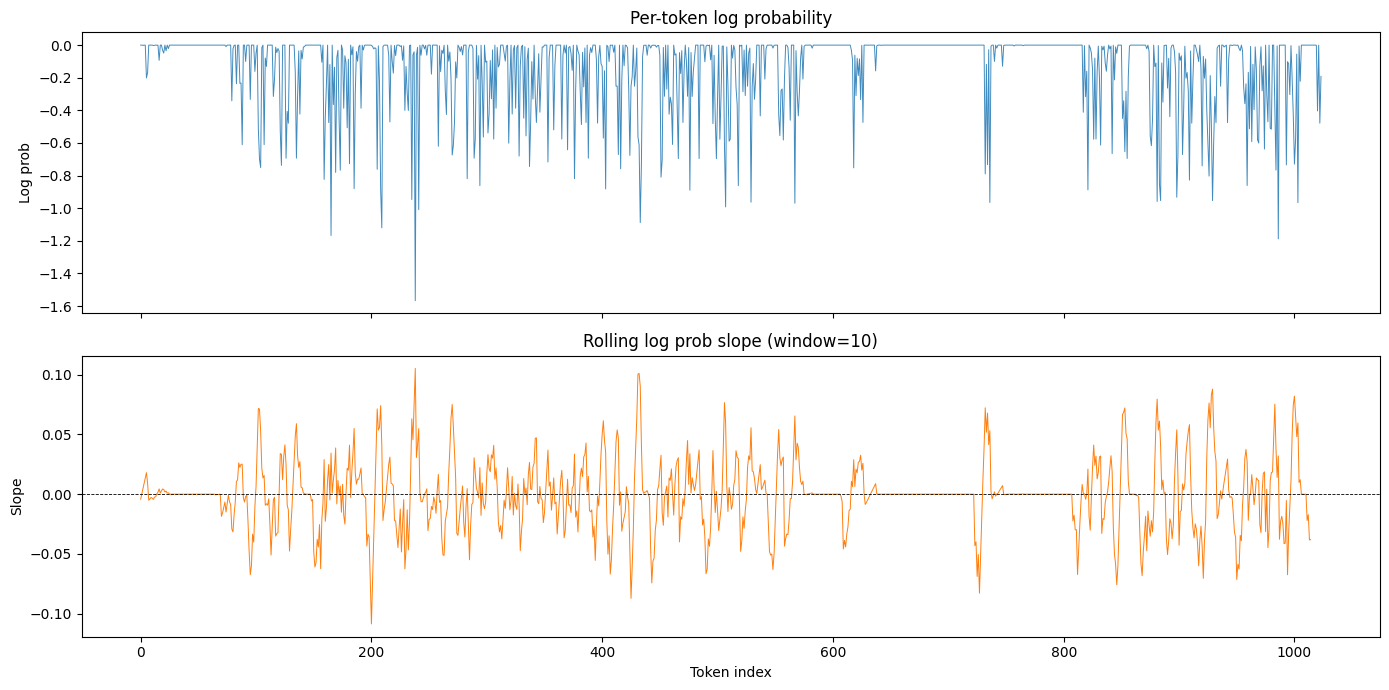

In [32]:
slopes = rolling_slope(token_log_probs, window=10)
slope_x = torch.arange(len(slopes)).cpu()

print(f"Generated {len(generated_ids)} tokens")
print(f"Mean log prob:  {token_log_probs.mean().item():.4f}")
print(f"</think> token: {think_end_pos}")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(token_log_probs.cpu().numpy(), linewidth=0.7, alpha=0.85, color="tab:blue")
if think_end_pos is not None:
    ax.axvline(think_end_pos, color="crimson", linestyle="--", linewidth=1.2, label=f"</think> @ {think_end_pos}")
    ax.legend(fontsize=9)
ax.set_ylabel("Log prob")
ax.set_title("Per-token log probability")

ax = axes[1]
ax.plot(slope_x.numpy(), slopes.cpu().numpy(), linewidth=0.7, color="tab:orange")
ax.axhline(0, color="k", linestyle="--", linewidth=0.6)
if think_end_pos is not None:
    ax.axvline(think_end_pos, color="crimson", linestyle="--", linewidth=1.2, label=f"</think> @ {think_end_pos}")
    ax.legend(fontsize=9)
ax.set_xlabel("Token index")
ax.set_ylabel("Slope")
ax.set_title("Rolling log prob slope (window=10)")

plt.tight_layout()
plt.show()

In [33]:
from IPython.display import HTML, display
import matplotlib.colors as mcolors
import numpy as np

WINDOW = 10

# Center-align each slope value to the middle token of its window
half = WINDOW // 2
T = len(decoded_tokens)
slope_aligned = np.full(T, np.nan)
for i, s in enumerate(slopes.cpu().numpy()):
    center = i + half
    if center < T:
        slope_aligned[center] = s

# Symmetric diverging colormap: blue = negative slope, red = positive slope
valid = slope_aligned[~np.isnan(slope_aligned)]
vmax = float(np.abs(valid).max()) if len(valid) else 1.0
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
cmap = plt.get_cmap("RdBu_r")

def slope_to_hex(s_val):
    if np.isnan(s_val):
        return "#d8d8d8"
    return mcolors.to_hex(cmap(norm(float(s_val))))

# Build one colored <span> per token
parts = []
for tok, s_val in zip(decoded_tokens, slope_aligned):
    display_tok = (
        tok.replace("&", "&amp;")
           .replace("<", "&lt;")
           .replace(">", "&gt;")
           .replace("\n", "↵<br>")
    )
    tooltip = f"{s_val:.5f}" if not np.isnan(s_val) else "n/a"
    bg = slope_to_hex(s_val)
    # darken text for very light backgrounds
    fg = "#000"
    parts.append(
        f'<span title="slope={tooltip}" style="background:{bg};color:{fg};'
        f'padding:1px 3px;border-radius:2px;font-family:monospace;font-size:13px;">'
        f'{display_tok}</span>'
    )

html_body = (
    '<p style="font-family:sans-serif;font-size:12px;margin-bottom:4px;">'
    '<b>Token log-prob slope</b> &mdash; '
    '<span style="background:#2166ac;color:white;padding:1px 5px;border-radius:2px;">blue</span> '
    'slope &lt; 0 (confidence falling) &nbsp;|&nbsp; '
    '<span style="background:#d6604d;color:white;padding:1px 5px;border-radius:2px;">red</span> '
    'slope &gt; 0 (confidence rising) &nbsp;|&nbsp; '
    '<span style="background:#d8d8d8;padding:1px 5px;border-radius:2px;">gray</span> '
    'no window yet</p>'
    '<div style="line-height:2.6;word-wrap:break-word;white-space:pre-wrap;border:1px solid #ccc;'
    'padding:10px;border-radius:4px;max-height:600px;overflow-y:auto;">'
    + "".join(parts)
    + "</div>"
)

display(HTML(html_body))

In [34]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def representation_drift(hidden_states):
    """
    hidden_states: tensor [T, D], one vector per generated token
    """
    h_prev = hidden_states[:-1]
    h_next = hidden_states[1:]

    l2_drift = torch.norm(h_next - h_prev, dim=-1)

    cosine_drift = 1 - F.cosine_similarity(h_next, h_prev, dim=-1)

    return {
        "l2": l2_drift,
        "cosine": cosine_drift,
    }


first_fen = ds["train"][0]["FEN"]

prompt = (
    "You are a chess expert. Given the position in FEN notation below, "
    "determine the best next move.\n\n"
    f"FEN: {first_fen}\n\n"
    "Output only the next move in standard algebraic notation (e.g. e4, Nf3, O-O). "
    "No explanation."
)
messages = [{"role": "user", "content": prompt}]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True,
)
inputs = tokenizer(text, return_tensors="pt").to(device)

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=1024,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        return_dict_in_generate=True,
        output_scores=True,
        output_hidden_states=True,
    )

In [35]:
# output.hidden_states: tuple[T] of tuple[num_layers+1] of [batch, seq_len, D]
# Step 0 has seq_len = full prompt length; later steps have seq_len = 1 (KV cache).
# Taking [0, -1, :] always picks the last (= newly generated) position.
hidden_per_token = torch.stack([
    step[-1][0, -1, :].float()
    for step in output.hidden_states
])  # [T, D]

drift = representation_drift(hidden_per_token)
l2_drift     = drift["l2"].cpu()      # [T-1]
cosine_drift = drift["cosine"].cpu()  # [T-1]

generated_ids   = output.sequences[0][inputs["input_ids"].shape[1]:]
scores          = torch.stack(output.scores).squeeze(1)  # [T, vocab_size]
token_log_probs_dr = F.log_softmax(scores, dim=-1).gather(
    1, generated_ids.unsqueeze(1)
).squeeze(1).float()  # [T]

decoded_tokens_dr = [tokenizer.decode([tid.item()]) for tid in generated_ids]
think_end_pos_dr  = next(
    (i for i, t in enumerate(decoded_tokens_dr) if "</think>" in t), None
)
slopes_dr = rolling_slope(token_log_probs_dr, window=20).cpu()

T = len(generated_ids)
print(f"Generated {T} tokens | hidden dim: {hidden_per_token.shape[1]}")
print(f"L2 drift     — min {l2_drift.min():.3f}  max {l2_drift.max():.3f}")
print(f"Cosine drift — min {cosine_drift.min():.5f}  max {cosine_drift.max():.5f}")

Generated 1024 tokens | hidden dim: 2048
L2 drift     — min 42.898  max 250.709
Cosine drift — min 0.04199  max 1.25757


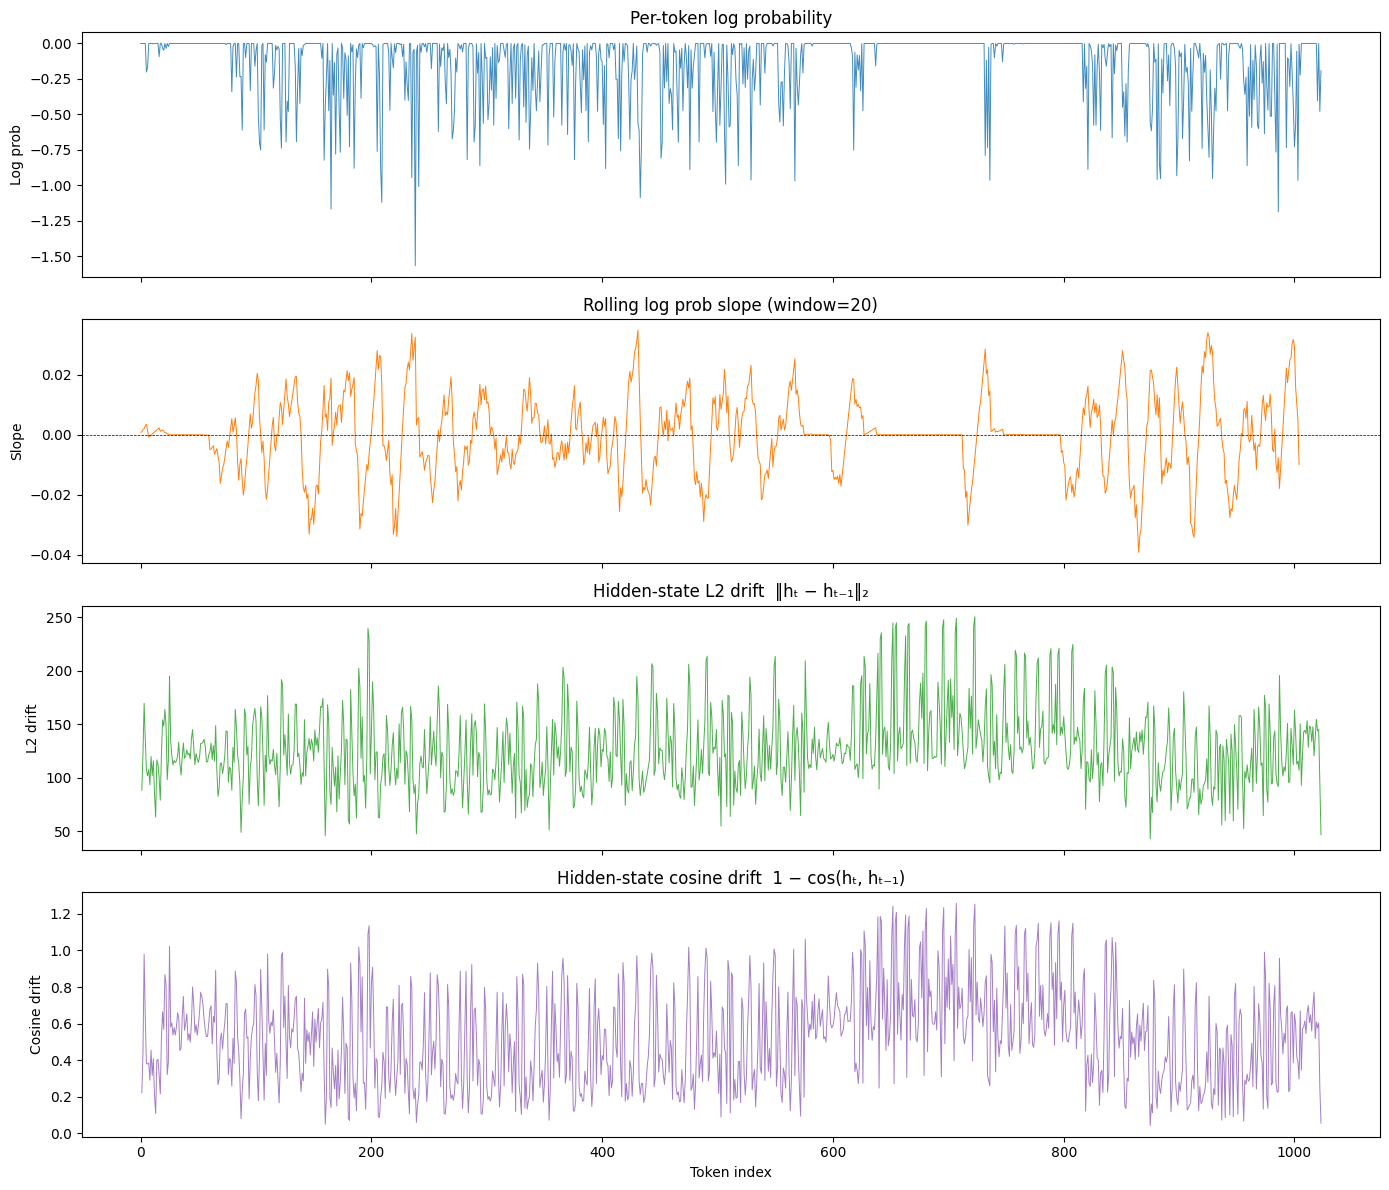

In [36]:
# ── 4-panel plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

def mark_think_end(ax, pos):
    if pos is not None:
        ax.axvline(pos, color="crimson", linestyle="--", linewidth=1.1,
                   label=f"</think> @ {pos}")
        ax.legend(fontsize=8)

# 1. per-token log prob
ax = axes[0]
ax.plot(token_log_probs_dr.cpu().numpy(), linewidth=0.7, color="tab:blue", alpha=0.85)
mark_think_end(ax, think_end_pos_dr)
ax.set_ylabel("Log prob")
ax.set_title("Per-token log probability")

# 2. rolling log prob slope
ax = axes[1]
ax.plot(slopes_dr.numpy(), linewidth=0.7, color="tab:orange")
ax.axhline(0, color="k", linestyle="--", linewidth=0.5)
mark_think_end(ax, think_end_pos_dr)
ax.set_ylabel("Slope")
ax.set_title("Rolling log prob slope (window=20)")

# 3. L2 drift — plot at the later token index (i+1) so x-axis stays aligned
drift_x = range(1, T)
ax = axes[2]
ax.plot(drift_x, l2_drift.numpy(), linewidth=0.7, color="tab:green", alpha=0.85)
mark_think_end(ax, think_end_pos_dr)
ax.set_ylabel("L2 drift")
ax.set_title("Hidden-state L2 drift  ‖hₜ − hₜ₋₁‖₂")

# 4. cosine drift
ax = axes[3]
ax.plot(drift_x, cosine_drift.numpy(), linewidth=0.7, color="tab:purple", alpha=0.85)
mark_think_end(ax, think_end_pos_dr)
ax.set_xlabel("Token index")
ax.set_ylabel("Cosine drift")
ax.set_title("Hidden-state cosine drift  1 − cos(hₜ, hₜ₋₁)")

plt.tight_layout()
plt.show()

In [37]:
from IPython.display import HTML, display
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# drift[i] = change from token i → token i+1; assign to the arriving token (i+1).
# Token 0 has no predecessor, so it gets NaN → gray.
T = len(decoded_tokens_dr)

def pad_drift(drift_tensor):
    """Prepend NaN so index i holds the drift *into* token i."""
    arr = np.empty(T)
    arr[0] = np.nan
    arr[1:] = drift_tensor.numpy()
    return arr

l2_aligned     = pad_drift(l2_drift)
cosine_aligned = pad_drift(cosine_drift)

def make_html_block(title, metric_arr, cmap_name, unit=""):
    cmap = plt.get_cmap(cmap_name)
    valid = metric_arr[~np.isnan(metric_arr)]
    vmin, vmax = float(valid.min()), float(valid.max())
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    parts = []
    for tok, val in zip(decoded_tokens_dr, metric_arr):
        display_tok = (
            tok.replace("&", "&amp;")
               .replace("<", "&lt;")
               .replace(">", "&gt;")
               .replace("\n", "↵<br>")
        )
        if np.isnan(val):
            bg, fg = "#d8d8d8", "#000"
            tooltip = "n/a"
        else:
            rgba = cmap(norm(float(val)))
            bg = mcolors.to_hex(rgba)
            # pick black or white text depending on luminance
            r, g, b = rgba[:3]
            lum = 0.2126 * r + 0.7152 * g + 0.0722 * b
            fg = "#000" if lum > 0.45 else "#fff"
            tooltip = f"{val:.5f}{unit}"

        parts.append(
            f'<span title="{title}={tooltip}" style="background:{bg};color:{fg};'
            f'padding:1px 3px;border-radius:2px;font-family:monospace;font-size:13px;">'
            f'{display_tok}</span>'
        )

    legend = (
        f'<p style="font-family:sans-serif;font-size:12px;margin:6px 0 3px 0;">'
        f'<b>{title}</b> &mdash; '
        f'<span style="background:{mcolors.to_hex(cmap(0.0))};padding:1px 6px;border-radius:2px;">low</span> '
        f'→ '
        f'<span style="background:{mcolors.to_hex(cmap(1.0))};color:#fff;padding:1px 6px;border-radius:2px;">high</span>'
        f' &nbsp; range [{vmin:.4f}, {vmax:.4f}]{unit}'
        f'</p>'
    )
    body = (
        '<div style="line-height:2.6;word-wrap:break-word;white-space:pre-wrap;'
        'border:1px solid #ccc;padding:10px;border-radius:4px;'
        'max-height:500px;overflow-y:auto;">'
        + "".join(parts)
        + "</div>"
    )
    return legend + body

html_l2     = make_html_block("L2 drift ‖hₜ−hₜ₋₁‖₂",          l2_aligned,     "YlOrRd")
html_cosine = make_html_block("Cosine drift 1−cos(hₜ,hₜ₋₁)",   cosine_aligned,  "YlGnBu")

display(HTML(html_l2))
display(HTML(html_cosine))

## With HotpotQA

In [38]:
from datasets import load_dataset

ds = load_dataset("hotpotqa/hotpot_qa", "fullwiki")

Generating test split: 100%|██████████| 7405/7405 [00:00<00:00, 23848.99 examples/s]


In [39]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from IPython.display import HTML, display

entry    = ds["train"][0]
question = entry["question"]
answer   = entry["answer"]

ctx_parts = []
for title, sentences in zip(entry["context"]["title"], entry["context"]["sentences"]):
    ctx_parts.append(f"{title}: " + " ".join(sentences))
context_str = "\n".join(ctx_parts)[:3000]

prompt = (
    "Answer the following multi-hop question. Use the provided context.\n\n"
    f"Context:\n{context_str}\n\n"
    f"Question: {question}\n\n"
    "Think through the reasoning steps, then give a concise final answer."
)

print(f"Question: {question}")
print(f"Answer:   {answer}")

messages = [{"role": "user", "content": prompt}]
text = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True, enable_thinking=True,
)
inputs = tokenizer(text, return_tensors="pt").to(device)

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=1024,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        return_dict_in_generate=True,
        output_scores=True,
        output_hidden_states=True,
    )

Question: Which magazine was started first Arthur's Magazine or First for Women?
Answer:   Arthur's Magazine


In [40]:


# ── metrics ───────────────────────────────────────────────────────────────────
generated_ids = output.sequences[0][inputs["input_ids"].shape[1]:]
scores        = torch.stack(output.scores).squeeze(1)

token_log_probs_hq = F.log_softmax(scores, dim=-1).gather(
    1, generated_ids.unsqueeze(1)
).squeeze(1).float()

hidden_per_token_hq = torch.stack([
    step[-1][0, -1, :].float() for step in output.hidden_states
])  # [T, D]

drift_hq  = representation_drift(hidden_per_token_hq)
l2_hq     = drift_hq["l2"].cpu()
cosine_hq = drift_hq["cosine"].cpu()

decoded_tokens_hq = [tokenizer.decode([tid.item()]) for tid in generated_ids]
think_end_hq      = next(
    (i for i, t in enumerate(decoded_tokens_hq) if "</think>" in t), None
)
slopes_hq = rolling_slope(token_log_probs_hq, window=20).cpu()

T_hq = len(generated_ids)
print(f"\nGenerated {T_hq} tokens | hidden dim: {hidden_per_token_hq.shape[1]}")
print(f"</think> token: {think_end_hq}")
print(f"L2 drift     — min {l2_hq.min():.3f}  max {l2_hq.max():.3f}")
print(f"Cosine drift — min {cosine_hq.min():.5f}  max {cosine_hq.max():.5f}")






Generated 415 tokens | hidden dim: 2048
</think> token: 352
L2 drift     — min 70.464  max 273.058
Cosine drift — min 0.10797  max 1.21755


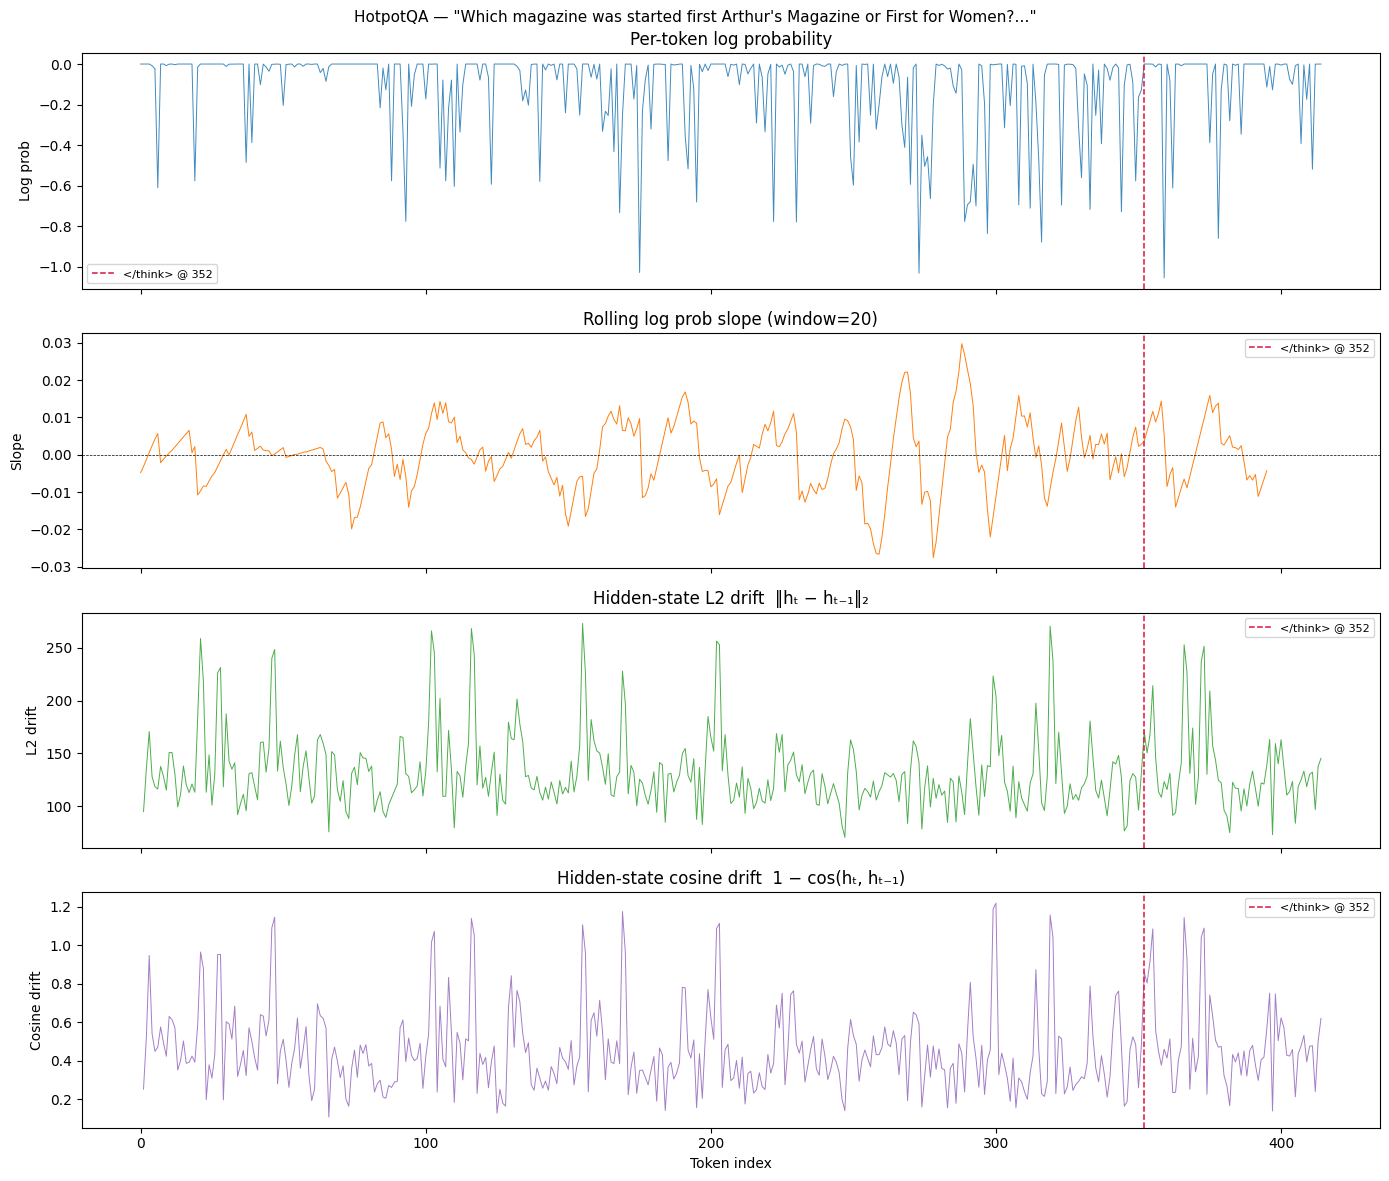

In [41]:
# ── 4-panel plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'HotpotQA — "{question[:80]}…"', fontsize=11)

def mark(ax, pos):
    if pos is not None:
        ax.axvline(pos, color="crimson", linestyle="--", linewidth=1.1,
                   label=f"</think> @ {pos}")
        ax.legend(fontsize=8)

drift_x_hq = range(1, T_hq)

axes[0].plot(token_log_probs_hq.cpu().numpy(), linewidth=0.7, color="tab:blue", alpha=0.85)
mark(axes[0], think_end_hq)
axes[0].set_ylabel("Log prob"); axes[0].set_title("Per-token log probability")

axes[1].plot(slopes_hq.numpy(), linewidth=0.7, color="tab:orange")
axes[1].axhline(0, color="k", linestyle="--", linewidth=0.5)
mark(axes[1], think_end_hq)
axes[1].set_ylabel("Slope"); axes[1].set_title("Rolling log prob slope (window=20)")

axes[2].plot(drift_x_hq, l2_hq.numpy(), linewidth=0.7, color="tab:green", alpha=0.85)
mark(axes[2], think_end_hq)
axes[2].set_ylabel("L2 drift"); axes[2].set_title("Hidden-state L2 drift  ‖hₜ − hₜ₋₁‖₂")

axes[3].plot(drift_x_hq, cosine_hq.numpy(), linewidth=0.7, color="tab:purple", alpha=0.85)
mark(axes[3], think_end_hq)
axes[3].set_xlabel("Token index")
axes[3].set_ylabel("Cosine drift"); axes[3].set_title("Hidden-state cosine drift  1 − cos(hₜ, hₜ₋₁)")

plt.tight_layout()
plt.show()

In [42]:
# ── shared HTML helpers ───────────────────────────────────────────────────────
def tokens_to_html(decoded_tokens, metric_arr, cmap, norm, title):
    parts = []
    for tok, val in zip(decoded_tokens, metric_arr):
        dt = (tok.replace("&", "&amp;").replace("<", "&lt;")
                 .replace(">", "&gt;").replace("\n", "↵<br>"))
        if np.isnan(val):
            bg, fg, tip = "#d8d8d8", "#000", "n/a"
        else:
            rgba = cmap(norm(float(val)))
            lum  = 0.2126*rgba[0] + 0.7152*rgba[1] + 0.0722*rgba[2]
            bg, fg, tip = mcolors.to_hex(rgba), ("#000" if lum > 0.45 else "#fff"), f"{val:.5f}"
        parts.append(
            f'<span title="{title}={tip}" style="background:{bg};color:{fg};'
            f'padding:1px 3px;border-radius:2px;font-family:monospace;font-size:13px;">{dt}</span>'
        )
    valid = metric_arr[~np.isnan(metric_arr)]
    lo, hi = float(valid.min()), float(valid.max())
    legend = (
        f'<p style="font-family:sans-serif;font-size:12px;margin:8px 0 3px 0;"><b>{title}</b>'
        f' &mdash; <span style="background:{mcolors.to_hex(cmap(0.0))};padding:1px 6px;border-radius:2px;">low</span>'
        f' → <span style="background:{mcolors.to_hex(cmap(1.0))};color:#fff;padding:1px 6px;border-radius:2px;">high</span>'
        f' &nbsp; range [{lo:.4f}, {hi:.4f}]</p>'
    )
    body = (
        '<div style="line-height:2.6;word-wrap:break-word;white-space:pre-wrap;'
        'border:1px solid #ccc;padding:10px;border-radius:4px;max-height:500px;overflow-y:auto;">'
        + "".join(parts) + "</div>"
    )
    return legend + body

# log-prob slope (diverging: blue=falling, red=rising)
WINDOW = 20
slope_aligned_hq = np.full(T_hq, np.nan)
for i, s in enumerate(slopes_hq.numpy()):
    center = i + WINDOW // 2
    if center < T_hq:
        slope_aligned_hq[center] = s
valid_s = slope_aligned_hq[~np.isnan(slope_aligned_hq)]
vmax_s  = float(np.abs(valid_s).max()) if len(valid_s) else 1.0

display(HTML(tokens_to_html(
    decoded_tokens_hq, slope_aligned_hq,
    plt.get_cmap("RdBu_r"),
    mcolors.TwoSlopeNorm(vmin=-vmax_s, vcenter=0.0, vmax=vmax_s),
    "Log-prob slope",
)))

# L2 drift (sequential: yellow=low, red=high)
l2_arr = np.empty(T_hq); l2_arr[0] = np.nan; l2_arr[1:] = l2_hq.numpy()
display(HTML(tokens_to_html(
    decoded_tokens_hq, l2_arr,
    plt.get_cmap("YlOrRd"),
    mcolors.Normalize(vmin=float(l2_hq.min()), vmax=float(l2_hq.max())),
    "L2 drift ‖hₜ−hₜ₋₁‖₂",
)))

# cosine drift (sequential: yellow=low, blue=high)
cos_arr = np.empty(T_hq); cos_arr[0] = np.nan; cos_arr[1:] = cosine_hq.numpy()
display(HTML(tokens_to_html(
    decoded_tokens_hq, cos_arr,
    plt.get_cmap("YlGnBu"),
    mcolors.Normalize(vmin=float(cosine_hq.min()), vmax=float(cosine_hq.max())),
    "Cosine drift 1−cos(hₜ,hₜ₋₁)",
)))

Question : Which magazine was started first Arthur's Magazine or First for Women?
Answer   : Arthur's Magazine
Generated: 475 tokens
Response : The provided context does not mention "Arthur's Magazine" or "First for Women," nor does it provide any information about their founding dates. Therefore, the question cannot be answered based on the given information. 

**Answer:** The context does not provide sufficient information to determine which magazine was started first.

Thinking (first 600 chars):
Okay, let's try to figure out which magazine was started first between Arthur's Magazine and First for Women. 

First, I need to look at the context provided. The user mentioned two magazines: Arthur's Magazine and First for Women. But the context given doesn't directly mention these magazines. Wait, maybe there's a mistake here. Let me check again.

Looking through the context, there's a mention of "First Arthur County Courthouse and Jail" but that's about a courthouse, not a magazine. The

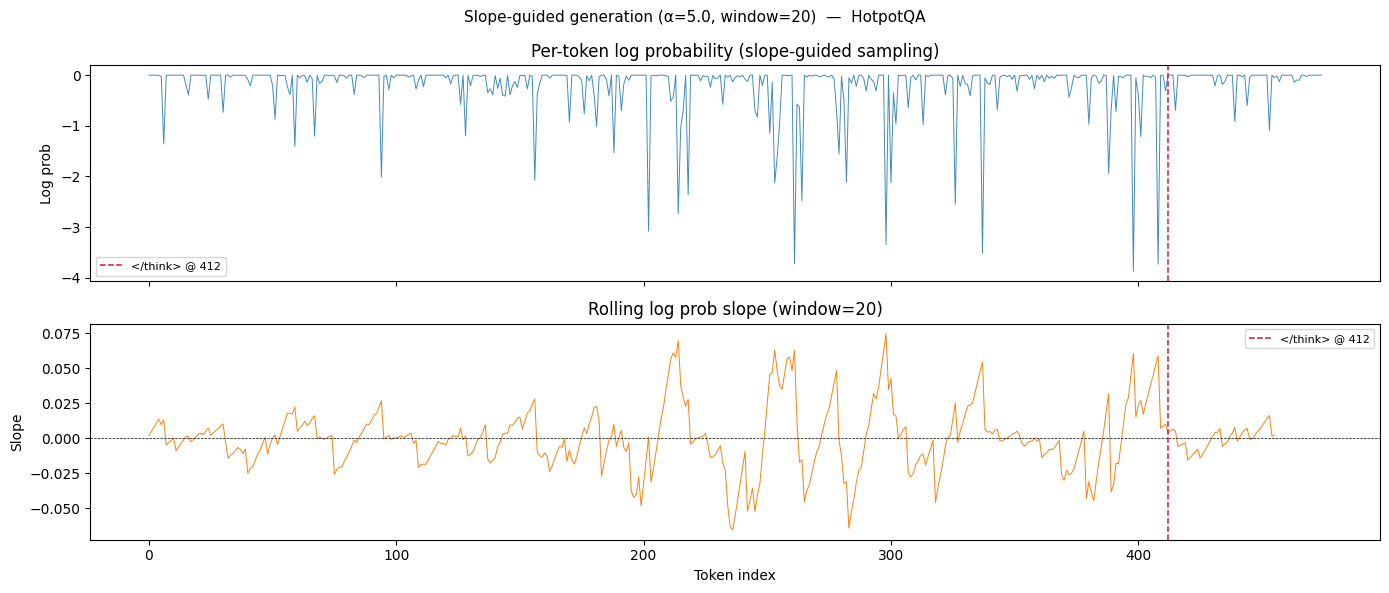

In [43]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Reuse question/answer/inputs from the HotpotQA cell above.
# At each step we add alpha * projected_slope[k] to each candidate token's logit,
# where projected_slope[k] = (hist_dot + x[-1] * log_prob[k]) / denom.
# Since projected_slope is linear in log_prob[k], this sharpens the distribution
# (equivalent to dynamic temperature scaling) with strength driven by alpha and
# the sign/magnitude of the recent log-prob trend.

ALPHA = 5.0   # bonus strength — increase to push harder toward high-slope tokens
WINDOW = 20
MAX_NEW_TOKENS = 1024

x_win = torch.arange(WINDOW, dtype=torch.float32, device=device) - (WINDOW - 1) / 2.0
denom = (x_win ** 2).sum()

input_ids_sg = inputs["input_ids"].clone()
past_kv = None
log_prob_history = []
gen_ids = []

for step in range(MAX_NEW_TOKENS):
    with torch.no_grad():
        if past_kv is None:
            out = model(input_ids=input_ids_sg, use_cache=True)
        else:
            out = model(
                input_ids=input_ids_sg[:, -1:],
                past_key_values=past_kv,
                use_cache=True,
            )
        past_kv = out.past_key_values
        logits = out.logits[0, -1]  # [vocab_size]

    log_probs = F.log_softmax(logits, dim=-1)  # [vocab_size]

    if len(log_prob_history) >= WINDOW - 1:
        recent = torch.tensor(
            log_prob_history[-(WINDOW - 1):], dtype=torch.float32, device=device
        )
        hist_dot = (x_win[:-1] * recent).sum()
        # projected_slope[k] = (hist_dot + x_win[-1] * log_probs[k]) / denom
        bonus = ALPHA * (hist_dot + x_win[-1] * log_probs) / denom
    else:
        bonus = torch.zeros_like(logits)

    modified_logits = logits + bonus

    # Sample from the bonus-modified distribution
    probs = F.softmax(modified_logits, dim=-1)
    next_id = torch.multinomial(probs, 1)

    log_prob_history.append(log_probs[next_id].item())
    gen_ids.append(next_id.item())
    input_ids_sg = next_id.unsqueeze(0)

    if next_id.item() == tokenizer.eos_token_id:
        break

# ── decode ────────────────────────────────────────────────────────────────────
decoded_sg = tokenizer.decode(torch.tensor(gen_ids), skip_special_tokens=False)

think_start = decoded_sg.find("<think>")
think_end   = decoded_sg.find("</think>")
if think_end != -1:
    thinking_sg = decoded_sg[think_start + 7 : think_end].strip() if think_start != -1 else ""
    response_sg = decoded_sg[think_end + 8 :].replace("<|im_end|>", "").strip()
else:
    thinking_sg = decoded_sg.strip()
    response_sg = "(reasoning did not conclude within token budget)"

print(f"Question : {question}")
print(f"Answer   : {answer}")
print(f"Generated: {len(gen_ids)} tokens")
print(f"Response : {response_sg}")
if thinking_sg:
    print(f"\nThinking (first 600 chars):\n{thinking_sg[:600]}")

# find </think> token index
decoded_toks_sg = [tokenizer.decode([tid]) for tid in gen_ids]
think_end_sg = next((i for i, t in enumerate(decoded_toks_sg) if "</think>" in t), None)

# ── plot ──────────────────────────────────────────────────────────────────────
lp_tensor_sg = torch.tensor(log_prob_history, dtype=torch.float32)
slopes_sg    = rolling_slope(lp_tensor_sg, window=WINDOW)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle(f"Slope-guided generation (α={ALPHA}, window={WINDOW})  —  HotpotQA", fontsize=11)

def mark(ax, pos):
    if pos is not None:
        ax.axvline(pos, color="crimson", linestyle="--", linewidth=1.1,
                   label=f"</think> @ {pos}")
        ax.legend(fontsize=8)

axes[0].plot(log_prob_history, linewidth=0.7, color="tab:blue", alpha=0.85)
mark(axes[0], think_end_sg)
axes[0].set_ylabel("Log prob")
axes[0].set_title("Per-token log probability (slope-guided sampling)")

axes[1].plot(slopes_sg.numpy(), linewidth=0.7, color="tab:orange")
axes[1].axhline(0, color="k", linestyle="--", linewidth=0.5)
mark(axes[1], think_end_sg)
axes[1].set_xlabel("Token index")
axes[1].set_ylabel("Slope")
axes[1].set_title(f"Rolling log prob slope (window={WINDOW})")

plt.tight_layout()
plt.show()

In [45]:
print(thinking_sg)

Okay, let's try to figure out which magazine was started first between Arthur's Magazine and First for Women. 

First, I need to look at the context provided. The user mentioned two magazines: Arthur's Magazine and First for Women. But the context given doesn't directly mention these magazines. Wait, maybe there's a mistake here. Let me check again.

Looking through the context, there's a mention of "First Arthur County Courthouse and Jail" but that's about a courthouse, not a magazine. Then there's a part about "Women's colleges in the Southern United States" and "Salem College," but that's about educational institutions. 

Wait, maybe the question is a trick question. The user might have confused the names. Let me check if "Arthur's Magazine" and "First for Women" are mentioned in the context. 

Looking through the context again, I don't see any references to magazines. The only mentions are about Radio City, Echosmith, the history of Albanian football, and some college information. 